In [91]:
import pandas as pd
import numpy as np 
import matplotlib.pyplot as plt
import seaborn as sns 

In [92]:
df = pd.read_csv("climate_data_2010_2025.csv")

In [93]:
df.head()

,Date,Latitude,Longitude,Max_Temperature,Min_Temperature,Rainfall
0,2010-01-01,8.5,77.5,32.04,22.81,0.0
1,2010-01-01,8.5,78.5,31.11,22.65,0.0
2,2010-01-01,9.5,76.5,31.27,21.50,0.0
3,2010-01-01,9.5,77.5,30.67,21.35,0.0
4,2010-01-01,9.5,78.5,29.44,20.85,0.0


In [94]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1929651 entries, 0 to 1929650
Data columns (total 6 columns):
 #   Column           Dtype  
---  ------           -----  
 0   Date             object 
 1   Latitude         float64
 2   Longitude        float64
 3   Max_Temperature  float64
 4   Min_Temperature  float64
 5   Rainfall         float64
dtypes: float64(5), object(1)
memory usage: 88.3+ MB


In [95]:
df.shape

(1929651, 6)

In [96]:
df.describe()

,Latitude,Longitude,Max_Temperature,Min_Temperature,Rainfall
count,1.929651e+06,1.929651e+06,1.929651e+06,1.929651e+06,1.929651e+06
mean,2.360236e+01,7.997014e+01,3.095360e+01,1.905098e+01,3.420983e+00
std,6.021268e+00,6.271866e+00,5.929023e+00,6.540145e+00,1.040221e+01
min,8.500000e+00,6.850000e+01,2.015030e+00,-8.820000e+00,0.000000e+00
25%,1.950000e+01,7.550000e+01,2.810998e+01,1.468000e+01,0.000000e+00
50%,2.450000e+01,7.850000e+01,3.134000e+01,2.087535e+01,0.000000e+00
75%,2.750000e+01,8.350000e+01,3.450275e+01,2.415795e+01,1.693357e+00
max,3.650000e+01,9.750000e+01,4.877099e+01,3.320000e+01,8.069304e+02


In [97]:
df.isnull().sum()

Date               0
Latitude           0
Longitude          0
Max_Temperature    0
Min_Temperature    0
Rainfall           0
dtype: int64

In [98]:
df.duplicated().sum()

np.int64(0)

In [99]:
df["Date"] = pd.to_datetime(df["Date"])

In [100]:
print(df.dtypes)

Date               datetime64[ns]
Latitude                  float64
Longitude                 float64
Max_Temperature           float64
Min_Temperature           float64
Rainfall                  float64
dtype: object


In [101]:
print(df[["Latitude", "Longitude",
          "Max_Temperature",
          "Min_Temperature",
          "Rainfall"]].describe())

           Latitude     Longitude  Max_Temperature  Min_Temperature  \
count  1.929651e+06  1.929651e+06     1.929651e+06     1.929651e+06   
mean   2.360236e+01  7.997014e+01     3.095360e+01     1.905098e+01   
std    6.021268e+00  6.271866e+00     5.929023e+00     6.540145e+00   
min    8.500000e+00  6.850000e+01     2.015030e+00    -8.820000e+00   
25%    1.950000e+01  7.550000e+01     2.810998e+01     1.468000e+01   
50%    2.450000e+01  7.850000e+01     3.134000e+01     2.087535e+01   
75%    2.750000e+01  8.350000e+01     3.450275e+01     2.415795e+01   
max    3.650000e+01  9.750000e+01     4.877099e+01     3.320000e+01   

           Rainfall  
count  1.929651e+06  
mean   3.420983e+00  
std    1.040221e+01  
min    0.000000e+00  
25%    0.000000e+00  
50%    0.000000e+00  
75%    1.693357e+00  
max    8.069304e+02  


In [102]:
df["Year"] = df["Date"].dt.year
df["Month"] = df["Date"].dt.month
df["Day"] = df["Date"].dt.day
df["DayOfYear"] = df["Date"].dt.dayofyear

In [103]:
def get_season(month):
    if month in [12, 1, 2]:
        return "Winter"
    elif month in [3, 4, 5]:
        return "Summer"
    elif month in [6, 7, 8, 9]:
        return "Monsoon"
    else:
        return "Post-Monsoon"

df["Season"] = df["Month"].apply(get_season)

print(df[["Date", "Year", "Month", "Day", "DayOfYear", "Season"]].head())

        Date  Year  Month  Day  DayOfYear  Season
0 2010-01-01  2010      1    1          1  Winter
1 2010-01-01  2010      1    1          1  Winter
2 2010-01-01  2010      1    1          1  Winter
3 2010-01-01  2010      1    1          1  Winter
4 2010-01-01  2010      1    1          1  Winter


In [104]:
print(df.shape)
print(df.columns)
print(df.describe())

(1929651, 11)
Index(['Date', 'Latitude', 'Longitude', 'Max_Temperature', 'Min_Temperature',
       'Rainfall', 'Year', 'Month', 'Day', 'DayOfYear', 'Season'],
      dtype='object')
                                Date      Latitude     Longitude  \
count                        1929651  1.929651e+06  1.929651e+06   
mean   2018-01-02 13:25:02.842742528  2.360236e+01  7.997014e+01   
min              2010-01-01 00:00:00  8.500000e+00  6.850000e+01   
25%              2014-01-04 00:00:00  1.950000e+01  7.550000e+01   
50%              2018-01-02 00:00:00  2.450000e+01  7.850000e+01   
75%              2022-01-03 00:00:00  2.750000e+01  8.350000e+01   
max              2025-12-31 00:00:00  3.650000e+01  9.750000e+01   
std                              NaN  6.021268e+00  6.271866e+00   

       Max_Temperature  Min_Temperature      Rainfall          Year  \
count     1.929651e+06     1.929651e+06  1.929651e+06  1.929651e+06   
mean      3.095360e+01     1.905098e+01  3.420983e+00  2.017506e

In [105]:
yearly_rain = df.groupby("Year")["Rainfall"].mean()
print(yearly_rain)

Year
2010    3.726109
2011    3.311030
2012    3.072785
2013    3.582749
2014    3.058749
2015    3.193517
2016    3.190052
2017    3.328070
2018    2.930233
2019    3.732167
2020    3.784860
2021    3.596129
2022    3.699436
2023    3.194219
2024    3.610548
2025    3.726027
Name: Rainfall, dtype: float64


In [106]:
monthly_rain = df.groupby("Month")["Rainfall"].mean()
print(monthly_rain)

Month
1     0.458802
2     0.595807
3     0.822951
4     1.543647
5     2.653657
6     6.175481
7     9.785519
8     8.414271
9     6.276874
10    2.619287
11    0.987335
12    0.506322
Name: Rainfall, dtype: float64


In [107]:
yearly_max = df.groupby("Year")["Max_Temperature"].mean()
print(yearly_max)

Year
2010    31.371254
2011    30.879178
2012    30.927072
2013    30.673052
2014    30.845179
2015    31.029460
2016    31.529489
2017    31.294063
2018    31.226814
2019    30.685970
2020    30.496126
2021    30.774704
2022    30.969197
2023    30.908305
2024    30.982777
2025    30.667187
Name: Max_Temperature, dtype: float64


In [108]:
yearly_min = df.groupby("Year")["Min_Temperature"].mean()
print(yearly_min)

Year
2010    19.449991
2011    18.664799
2012    18.586776
2013    18.822120
2014    18.742865
2015    19.114791
2016    19.256240
2017    19.109383
2018    18.845623
2019    19.123772
2020    18.904106
2021    19.085662
2022    19.179414
2023    19.116862
2024    19.655122
2025    19.157709
Name: Min_Temperature, dtype: float64


In [109]:
print(
    df[
        [
            "Latitude",
            "Longitude",
            "Max_Temperature",
            "Min_Temperature",
            "Rainfall",
        ]
    ].corr()
)

                 Latitude  Longitude  Max_Temperature  Min_Temperature  \
Latitude         1.000000   0.078156        -0.349204        -0.401213   
Longitude        0.078156   1.000000        -0.087610         0.025405   
Max_Temperature -0.349204  -0.087610         1.000000         0.821385   
Min_Temperature -0.401213   0.025405         0.821385         1.000000   
Rainfall        -0.046761   0.097683        -0.074001         0.161230   

                 Rainfall  
Latitude        -0.046761  
Longitude        0.097683  
Max_Temperature -0.074001  
Min_Temperature  0.161230  
Rainfall         1.000000  


In [110]:
season_map = {
    "Winter": 0,
    "Summer": 1,
    "Monsoon": 2,
    "Post-Monsoon": 3
}
df["Season"] = df["Season"].map(season_map)

In [111]:
print(df.head())
print(df.dtypes)

        Date  Latitude  Longitude  Max_Temperature  Min_Temperature  Rainfall  \
0 2010-01-01       8.5       77.5            32.04            22.81       0.0   
1 2010-01-01       8.5       78.5            31.11            22.65       0.0   
2 2010-01-01       9.5       76.5            31.27            21.50       0.0   
3 2010-01-01       9.5       77.5            30.67            21.35       0.0   
4 2010-01-01       9.5       78.5            29.44            20.85       0.0   

   Year  Month  Day  DayOfYear  Season  
0  2010      1    1          1       0  
1  2010      1    1          1       0  
2  2010      1    1          1       0  
3  2010      1    1          1       0  
4  2010      1    1          1       0  
Date               datetime64[ns]
Latitude                  float64
Longitude                 float64
Max_Temperature           float64
Min_Temperature           float64
Rainfall                  float64
Year                        int32
Month                       i

In [112]:
corr = df[
    [
        "Latitude",
        "Longitude",
        "Max_Temperature",
        "Min_Temperature",
        "Rainfall",
        "Year",
        "Month",
        "Day",
        "DayOfYear",
    ]
].corr()

print(corr)

                 Latitude  Longitude  Max_Temperature  Min_Temperature  \
Latitude         1.000000   0.078156        -0.349204        -0.401213   
Longitude        0.078156   1.000000        -0.087610         0.025405   
Max_Temperature -0.349204  -0.087610         1.000000         0.821385   
Min_Temperature -0.401213   0.025405         0.821385         1.000000   
Rainfall        -0.046761   0.097683        -0.074001         0.161230   
Year             0.001592   0.001937        -0.014286         0.018962   
Month           -0.000011   0.000019        -0.035449         0.100713   
Day             -0.000349  -0.000030         0.001716         0.000003   
DayOfYear       -0.000037   0.000021        -0.037698         0.097556   

                 Rainfall      Year     Month       Day  DayOfYear  
Latitude        -0.046761  0.001592 -0.000011 -0.000349  -0.000037  
Longitude        0.097683  0.001937  0.000019 -0.000030   0.000021  
Max_Temperature -0.074001 -0.014286 -0.035449  0.001

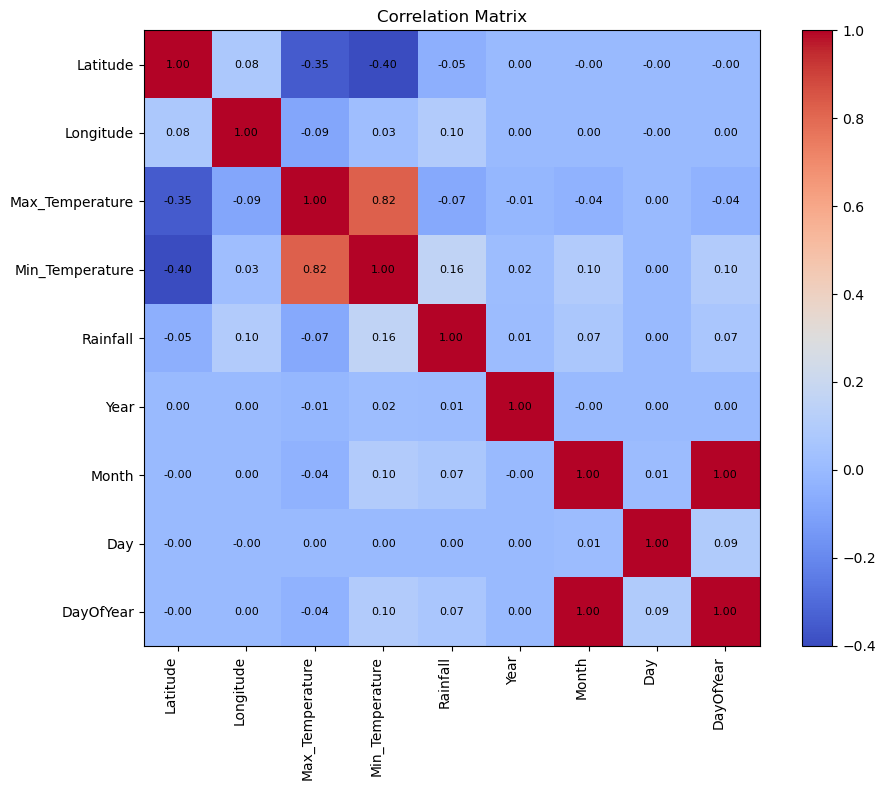

In [113]:
plt.figure(figsize=(10, 8))
plt.imshow(corr, cmap="coolwarm", interpolation="nearest")
plt.colorbar()
plt.xticks(
    np.arange(len(corr.columns)),
    corr.columns,
    rotation=90,
    ha="right"
)
plt.yticks(
    np.arange(len(corr.columns)),
    corr.columns
)
for i in range(len(corr.columns)):
    for j in range(len(corr.columns)):
        plt.text(
            j,
            i,
            f"{corr.iloc[i, j]:.2f}",
            ha="center",
            va="center",
            fontsize=8
        )

plt.title("Correlation Matrix")
plt.tight_layout()
plt.show()

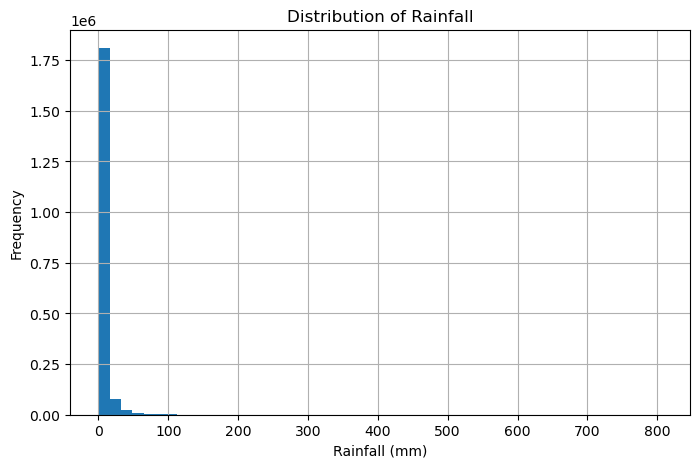

In [167]:
plt.figure(figsize=(8,5))
plt.hist(df["Rainfall"], bins=50)
plt.title("Distribution of Rainfall")
plt.xlabel("Rainfall (mm)")
plt.ylabel("Frequency")
plt.grid(True)
plt.show()

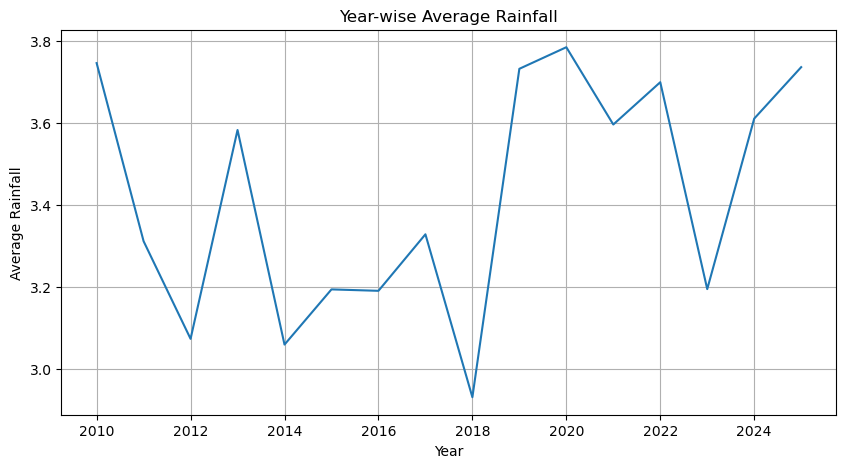

In [169]:
yearly = (
    df.groupby("Year")["Rainfall"]
      .mean()
      .reset_index())
plt.figure(figsize=(10,5))

plt.plot(
    yearly["Year"],
    yearly["Rainfall"])
plt.title("Year-wise Average Rainfall")
plt.xlabel("Year")
plt.ylabel("Average Rainfall")
plt.grid(True)
plt.show()

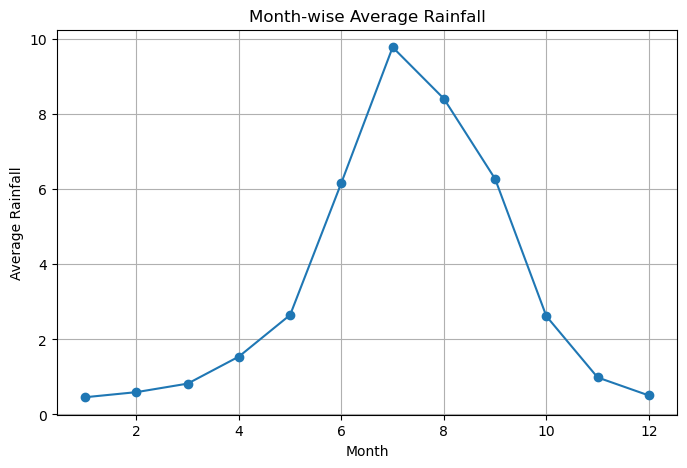

In [170]:
monthly = (
    df.groupby("Month")["Rainfall"]
      .mean()
      .reset_index())
plt.figure(figsize=(8,5))
plt.plot(
    monthly["Month"],
    monthly["Rainfall"],
    marker="o")
plt.title("Month-wise Average Rainfall")
plt.xlabel("Month")
plt.ylabel("Average Rainfall")
plt.grid(True)
plt.show()

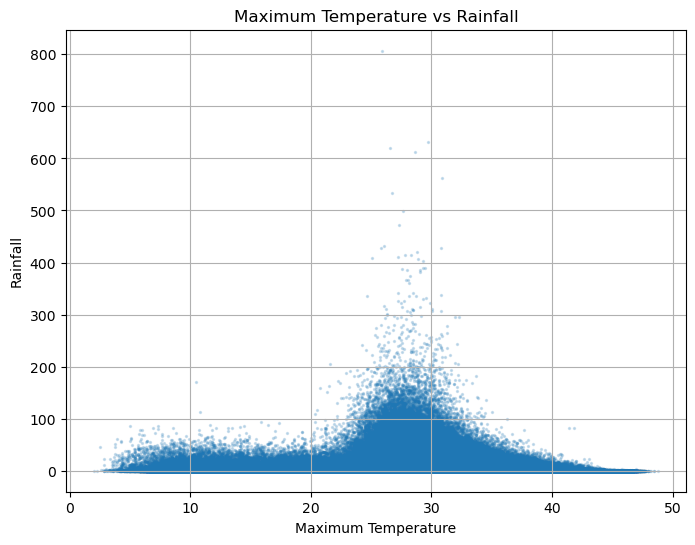

In [171]:
plt.figure(figsize=(8,6))
plt.scatter(
    df["Max_Temperature"],
    df["Rainfall"],
    s=2,
    alpha=0.2)
plt.xlabel("Maximum Temperature")
plt.ylabel("Rainfall")
plt.title("Maximum Temperature vs Rainfall")
plt.grid(True)
plt.show()

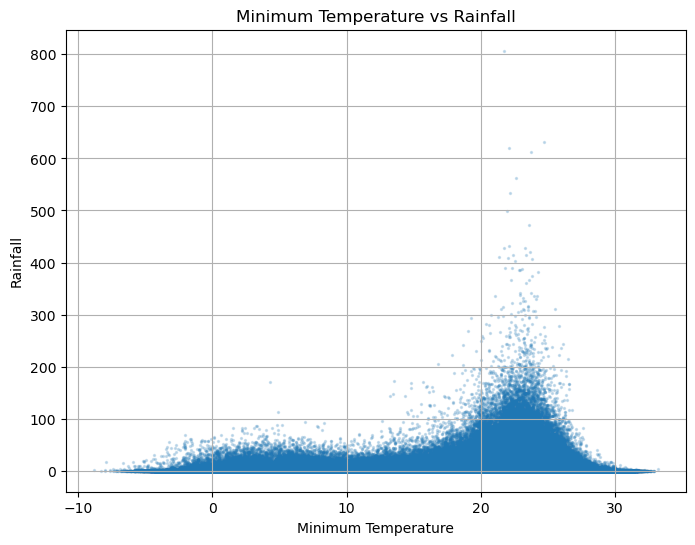

In [172]:
plt.figure(figsize=(8,6))
plt.scatter(
    df["Min_Temperature"],
    df["Rainfall"],
    s=2,
    alpha=0.2)
plt.xlabel("Minimum Temperature")
plt.ylabel("Rainfall")
plt.title("Minimum Temperature vs Rainfall")
plt.grid(True)
plt.show()

In [114]:
df_model = df.drop(columns=["Date", "Day", "DayOfYear"])
print(df_model.head())

   Latitude  Longitude  Max_Temperature  Min_Temperature  Rainfall  Year  \
0       8.5       77.5            32.04            22.81       0.0  2010   
1       8.5       78.5            31.11            22.65       0.0  2010   
2       9.5       76.5            31.27            21.50       0.0  2010   
3       9.5       77.5            30.67            21.35       0.0  2010   
4       9.5       78.5            29.44            20.85       0.0  2010   

   Month  Season  
0      1       0  
1      1       0  
2      1       0  
3      1       0  
4      1       0  


In [115]:
print(df["Date"].dtype)

datetime64[ns]


In [116]:
print(df[["Date", "Year", "Month", "Day"]].head())

        Date  Year  Month  Day
0 2010-01-01  2010      1    1
1 2010-01-01  2010      1    1
2 2010-01-01  2010      1    1
3 2010-01-01  2010      1    1
4 2010-01-01  2010      1    1


In [117]:
print(df[["Month", "Season"]].head(10))

   Month  Season
0      1       0
1      1       0
2      1       0
3      1       0
4      1       0
5      1       0
6      1       0
7      1       0
8      1       0
9      1       0


In [118]:
df = df.sort_values(
    by=["Latitude", "Longitude", "Date"]
).reset_index(drop=True)

In [119]:
print(df.head())

        Date  Latitude  Longitude  Max_Temperature  Min_Temperature  Rainfall  \
0 2010-01-01       8.5       77.5            32.04            22.81       0.0   
1 2010-01-02       8.5       77.5            31.97            23.14       0.0   
2 2010-01-03       8.5       77.5            31.88            22.55       0.0   
3 2010-01-04       8.5       77.5            31.60            22.80       0.0   
4 2010-01-05       8.5       77.5            31.72            21.45       0.0   

   Year  Month  Day  DayOfYear  Season  
0  2010      1    1          1       0  
1  2010      1    2          2       0  
2  2010      1    3          3       0  
3  2010      1    4          4       0  
4  2010      1    5          5       0  


In [120]:
df["Rainfall_Next_Day"] = (
    df.groupby(
        ["Latitude", "Longitude"]
    )["Rainfall"].shift(-1)
)

In [121]:
print(
    df[
        ["Date", "Rainfall", "Rainfall_Next_Day"]
    ].head(10)
)

        Date  Rainfall  Rainfall_Next_Day
0 2010-01-01  0.000000           0.000000
1 2010-01-02  0.000000           0.000000
2 2010-01-03  0.000000           0.000000
3 2010-01-04  0.000000           0.000000
4 2010-01-05  0.000000           0.000000
5 2010-01-06  0.000000           0.000000
6 2010-01-07  0.000000           0.000000
7 2010-01-08  0.000000           0.000000
8 2010-01-09  0.000000           6.766417
9 2010-01-10  6.766417          19.261337


In [122]:
df = df.dropna().reset_index(drop=True)
print(df.shape)
print(df.isnull().sum())

(1929320, 12)
Date                 0
Latitude             0
Longitude            0
Max_Temperature      0
Min_Temperature      0
Rainfall             0
Year                 0
Month                0
Day                  0
DayOfYear            0
Season               0
Rainfall_Next_Day    0
dtype: int64


In [123]:
features = [
    "Latitude",
    "Longitude",
    "Max_Temperature",
    "Min_Temperature",
    "Rainfall",
    "Year",
    "Month",
    "Season"
]

target = "Rainfall_Next_Day"

In [124]:
X = df[features]
y = df[target]

print("X Shape:", X.shape)
print("y Shape:", y.shape)

X Shape: (1929320, 8)
y Shape: (1929320,)


In [125]:
train_df = df[df["Year"] <= 2023]
test_df = df[df["Year"] >= 2024]

X_train = train_df[features]
y_train = train_df[target]

X_test = test_df[features]
y_test = test_df[target]

print("Training Shape :", X_train.shape)
print("Testing Shape  :", X_test.shape)

Training Shape : (1687869, 8)
Testing Shape  : (241451, 8)


In [126]:
from sklearn.ensemble import HistGradientBoostingRegressor

model = HistGradientBoostingRegressor(
    max_iter=300,
    learning_rate=0.05,
    max_depth=8,
    random_state=42
)

In [127]:
model.fit(X_train, y_train)

,loss,'squared_error'
,quantile,None
,learning_rate,0.05
,max_iter,300
,max_leaf_nodes,31
,max_depth,8
,min_samples_leaf,20
,l2_regularization,0.0
,max_features,1.0
,max_bins,255
,categorical_features,'from_dtype'


In [128]:
y_pred = model.predict(X_test)
print(y_pred[:10])

[ 1.61850376  1.60392128  1.25830149  2.39870096  1.83550786  2.39870096
  6.81865409  5.88880296 14.08081259  4.9899142 ]


In [129]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print("MAE :", mae)
print("RMSE:", rmse)
print("R² Score:", r2)

MAE : 3.2580619998233016
RMSE: 8.109355814321226
R² Score: 0.43637418376312676


In [130]:
print(df.columns.tolist())

['Date', 'Latitude', 'Longitude', 'Max_Temperature', 'Min_Temperature', 'Rainfall', 'Year', 'Month', 'Day', 'DayOfYear', 'Season', 'Rainfall_Next_Day']


In [161]:
df = df.sort_values(
    by=["Latitude", "Longitude", "Date"]
).reset_index(drop=True)

df["Rainfall_Lag1"] = (
    df.groupby(["Latitude", "Longitude"])["Rainfall"].shift(1)
)
 
df["MaxTemp_Lag1"] = (
    df.groupby(["Latitude", "Longitude"])["Max_Temperature"].shift(1)
)
 
df["MinTemp_Lag1"] = (
    df.groupby(["Latitude", "Longitude"])["Min_Temperature"].shift(1)
)

In [162]:
df = df.dropna().reset_index(drop=True)
print(df.isnull().sum())
print(df.shape)

Date                 0
Latitude             0
Longitude            0
Max_Temperature      0
Min_Temperature      0
Rainfall             0
Year                 0
Month                0
Day                  0
DayOfYear            0
Season               0
Rainfall_Next_Day    0
Rainfall_Lag1        0
MaxTemp_Lag1         0
MinTemp_Lag1         0
Temp_Difference      0
Rainfall_Rolling3    0
Rainfall_Rolling7    0
dtype: int64
(1928658, 18)


In [163]:
print(df.columns.tolist())

['Date', 'Latitude', 'Longitude', 'Max_Temperature', 'Min_Temperature', 'Rainfall', 'Year', 'Month', 'Day', 'DayOfYear', 'Season', 'Rainfall_Next_Day', 'Rainfall_Lag1', 'MaxTemp_Lag1', 'MinTemp_Lag1', 'Temp_Difference', 'Rainfall_Rolling3', 'Rainfall_Rolling7']


New feature to improve accuracy 

In [164]:
features = [
    "Latitude",
    "Longitude",
    "Max_Temperature",
    "Min_Temperature",
    "Rainfall",
    "Rainfall_Lag1",
    "MaxTemp_Lag1",
    "MinTemp_Lag1",
    "Year",
    "Month",
    "Season"
]
target = "Rainfall_Next_Day"

In [165]:
X = df[features]
y = df[target]
print("X Shape:", X.shape)
print("y Shape:", y.shape)

X Shape: (1928658, 11)
y Shape: (1928658,)


In [166]:
train_df = df[df["Year"] <= 2023]
test_df = df[df["Year"] >= 2024]

X_train = train_df[features]
y_train = train_df[target]

X_test = test_df[features]
y_test = test_df[target]

print("Training Shape:", X_train.shape)
print("Testing Shape :", X_test.shape)

Training Shape: (1687207, 11)
Testing Shape : (241451, 11)


In [137]:
from sklearn.ensemble import HistGradientBoostingRegressor

model = HistGradientBoostingRegressor(
    max_iter=300,
    learning_rate=0.05,
    max_depth=8,
    random_state=42
)

In [138]:
model.fit(X_train, y_train)

,loss,'squared_error'
,quantile,None
,learning_rate,0.05
,max_iter,300
,max_leaf_nodes,31
,max_depth,8
,min_samples_leaf,20
,l2_regularization,0.0
,max_features,1.0
,max_bins,255
,categorical_features,'from_dtype'


In [139]:
y_pred = model.predict(X_test)
print(y_pred[:10])

[1.60807684 1.03313284 1.09230353 2.01871817 1.66131598 1.29681027
 5.17553097 5.68966689 9.46251728 4.54335977]


In [140]:
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)
import numpy as np

mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print("MAE :", mae)
print("RMSE:", rmse)
print("R² Score:", r2)

MAE : 3.1871677114833625
RMSE: 8.006207227078365
R² Score: 0.4506212988328627


In [141]:
comparison = pd.DataFrame({
    "Actual": y_test.values,
    "Predicted": y_pred
})

print(comparison.head(20))

      Actual  Predicted
0   0.000000   1.608077
1   0.000000   1.033133
2   0.000000   1.092304
3   0.000000   2.018718
4   0.000000   1.661316
5   2.377389   1.296810
6   1.660527   5.175531
7   0.553774   5.689667
8   2.811462   9.462517
9   1.788568   4.543360
10  0.000000   2.902422
11  0.000000   1.688801
12  0.000000   0.354381
13  0.000000   0.716957
14  0.000000   0.548400
15  0.000000   0.260313
16  0.000000  -0.054988
17  0.000000   0.209484
18  0.000000   1.042735
19  0.478395   1.938698


to improve more predection accuracy of data set 

In [142]:
df["Temp_Difference"] = (
    df["Max_Temperature"] - df["Min_Temperature"]
)

In [143]:
df["Rainfall_Rolling3"] = (
    df.groupby(["Latitude", "Longitude"])["Rainfall"]
      .transform(lambda x: x.rolling(3, min_periods=1).mean())
)

In [144]:
df["Rainfall_Rolling7"] = (
    df.groupby(["Latitude", "Longitude"])["Rainfall"]
      .transform(lambda x: x.rolling(7, min_periods=1).mean())
)

In [145]:
from sklearn.ensemble import HistGradientBoostingRegressor

model = HistGradientBoostingRegressor(
    max_iter=500,
    learning_rate=0.03,
    max_depth=10,
    min_samples_leaf=20,
    random_state=42
)

In [146]:
features = [
    "Latitude",
    "Longitude",
    "Max_Temperature",
    "Min_Temperature",
    "Temp_Difference",
    "Rainfall",
    "Rainfall_Lag1",
    "Rainfall_Rolling3",
    "Rainfall_Rolling7",
    "MaxTemp_Lag1",
    "MinTemp_Lag1",
    "Year",
    "Month",
    "Season"
]

target = "Rainfall_Next_Day"

In [147]:
X = df[features]
y = df[target]

print(X.shape)
print(y.shape)

(1928989, 14)
(1928989,)


In [148]:
train_df = df[df["Year"] <= 2023]
test_df = df[df["Year"] >= 2024]

X_train = train_df[features]
y_train = train_df[target]

X_test = test_df[features]
y_test = test_df[target]

print(X_train.shape)
print(X_test.shape)

(1687538, 14)
(241451, 14)


In [149]:
model.fit(X_train, y_train)

,loss,'squared_error'
,quantile,None
,learning_rate,0.03
,max_iter,500
,max_leaf_nodes,31
,max_depth,10
,min_samples_leaf,20
,l2_regularization,0.0
,max_features,1.0
,max_bins,255
,categorical_features,'from_dtype'


In [150]:
y_pred = np.maximum(y_pred, 0)

In [151]:
from sklearn.metrics import (mean_absolute_error,mean_squared_error,r2_score)
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print("MAE :", mae)
print("RMSE:", rmse)
print("R² Score:", r2)

MAE : 3.181290468272446
RMSE: 8.006137168723486
R² Score: 0.450630913472734


In [152]:
from xgboost import XGBRegressor
model = XGBRegressor(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=8,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    n_jobs=-1
)

In [153]:
model.fit(X_train, y_train)

,objective,'reg:squarederror'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,0.8
,device,None
,early_stopping_rounds,None
,enable_categorical,True
,eval_metric,None


In [154]:
y_pred = model.predict(X_test)

In [155]:
y_pred = np.maximum(y_pred, 0)

In [156]:
from sklearn.metrics import (mean_absolute_error,mean_squared_error,r2_score)
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print("MAE :", mae)
print("RMSE:", rmse)
print("R² Score:", r2)

MAE : 3.155772460950675
RMSE: 8.060283488791153
R² Score: 0.4431749075511694


In [157]:
from lightgbm import LGBMRegressor

model = LGBMRegressor(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=8,
    random_state=42
)

In [158]:
model.fit(X_train, y_train)

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.019059 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 2388
[LightGBM] [Info] Number of data points in the train set: 1687538, number of used features: 14
[LightGBM] [Info] Start training from score 3.386189


,boosting_type,'gbdt'
,num_leaves,31
,max_depth,8
,learning_rate,0.05
,n_estimators,300
,subsample_for_bin,200000
,objective,None
,class_weight,None
,min_split_gain,0.0
,min_child_weight,0.001
,min_child_samples,20


In [159]:
model.fit(X_train, y_train)
y_pred = model.predict(X_test)
y_pred = np.maximum(y_pred, 0)

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.018552 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 2388
[LightGBM] [Info] Number of data points in the train set: 1687538, number of used features: 14
[LightGBM] [Info] Start training from score 3.386189


In [160]:
from sklearn.metrics import (mean_absolute_error,mean_squared_error,r2_score)
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print("MAE :", mae)
print("RMSE:", rmse)
print("R² Score:", r2)

MAE : 3.1908961027918052
RMSE: 8.015671014273368
R² Score: 0.4493217381682433
